In [2]:
from utils import *
from utils_fmri import * 

<h1 align='center'> Correlations and confounds </h1>

## task structure

In [ ]:
#--------------------- helpers

def time_poly_basis(onsets, degrees=(1, 2), eps=1e-12):
    """
    Return array with columns for |Δt|^d where higher orders are residualized
    on all lower orders (with intercept). Optionally z-score columns.
    Shape: [n_pairs, len(degrees)].
    """
    def orth_residualize(x, *others):
        n = len(x)
        if not others:
            return x - x.mean()
        X = np.column_stack([np.ones(n), *others])
        beta, *_ = np.linalg.lstsq(X, x, rcond=None)
        return x - X @ beta

    def zscore(x):
        x = np.asarray(x, float)
        return (x - x.mean()) / (x.std(ddof=1) + eps)

    dt   = pdist(np.asarray(onsets, float).reshape(-1, 1), metric='euclidean')
    degs = tuple(sorted(degrees))

    cols = []
    for j, d in enumerate(degs):
        x = dt ** d
        if j > 0:  # make 'unique' by removing projections on lower orders
            x = orth_residualize(x, *cols)
        cols.append(x)
    return np.column_stack(cols)

def per_character_rdvs(char_id_vec):
    """
    Return dict {character_value: rdv_vector} where each RDV is 1 for
    within-character pairs (both endpoints == that character), else 0.

    The RDVs are in SciPy's condensed order (same as pdist).
    """
    char_id_vec = np.asarray(char_id_vec)
    chars = np.unique(char_id_vec)
    out = {}
    for c in chars:
        mask = (char_id_vec == c).astype(float)  # length T
        M = np.outer(mask, mask)                 # T x T, 1 only if both endpoints are c
        np.fill_diagonal(M, 0.0)                 # hollow
        out[c] = squareform(M, checks=False).astype(float)
    return out

def plot_heatmap(M, title, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(M, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("trial j")
    ax.set_ylabel("trial i")
    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

# ----------------------------
# Trialwise variables
# ----------------------------

onsets = decision_trials['onset'].values
lag_rdm = np.abs(onsets[:, None] - onsets[None, :]) # Lag: |t_i - t_j|
midpoint_rdm = (onsets[:, None] + onsets[None, :]) / 2.0 # Midpoint: (t_i + t_j)/2

# ----------------------------
# Confound RDVs
# ----------------------------

char_fam = decision_trials['character_decision_num'].values
char_id  = decision_trials['character_role_num'].values
scene_id = pd.factorize(decision_trials['scene'].values, sort=False)[0]
dims     = (decision_trials['dimension'].values == 'affil').astype(int)

char_fam_rdv = pdist(char_fam.reshape(-1, 1), metric='euclidean')
scene_rdv    = pdist(scene_id.reshape(-1, 1), metric='hamming')
char_id_rdv  = pdist(char_id.reshape(-1, 1), metric='hamming')
dim_rdv      = pdist(dims.reshape(-1, 1), metric='hamming')

# Convert RDVs -> RDMs
char_fam_rdm = squareform(char_fam_rdv)
scene_rdm    = squareform(scene_rdv)
char_id_rdm  = squareform(char_id_rdv).astype(float)
dim_rdm      = squareform(dim_rdv)

# ----------------------------
# Average behavioral RDM
# ----------------------------

cumsum_rdms, runmean_rdms = [], []
for sub_id in incl_subs:
    beh = load_behavior(sub_id, neutrals=True)
    cumsum_rdms.append(squareform(pdist(beh[['affil_coord', 'power_coord']].values, metric='euclidean')))
    runmean_rdms.append(squareform(pdist(beh[['affil_runmean', 'power_runmean']].values, metric='euclidean')))
cumsum_rdm  = np.nanmean(np.stack(cumsum_rdms, axis=0), axis=0)
runmean_rdm = np.nanmean(np.stack(runmean_rdms, axis=0), axis=0)

# ----------------------------
# Plot
# ----------------------------

mats = {
    "Time lag": lag_rdm,
    "Time to midpoint": midpoint_rdm,
    "Scene": scene_rdm,
    "Dimension": dim_rdm,
    "Character identity": char_id_rdm,
    "Character familiarity": char_fam_rdm,
    "2D cumulative sum (empirical avg.)": cumsum_rdm,
    "2D runmean (empirical avg.)": runmean_rdm,
}

n = len(mats)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4), constrained_layout=True)
for ax, (name, M) in zip(axes, mats.items()):
    # binary vs continuous scaling
    if name.lower() in {"same scene", "character identity", "dimension"}:
        vmin, vmax = 0, 1
    else:
        vmin, vmax = 0, np.nanmax(M)

    plot_heatmap(
        M,
        title=name,
        ax=ax,
    )

    ax.set_xlabel("Trial")
    ax.set_ylabel("Trial")
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


In [ ]:
from scipy.stats import spearmanr, pearsonr

def _rdm_to_vec(M):
    """Vectorize upper triangle (k=1) of a square RDM."""
    M = np.asarray(M, float)
    assert M.ndim == 2 and M.shape[0] == M.shape[1], f"RDM must be square; got {M.shape}"
    iu = np.triu_indices(M.shape[0], k=1)
    v = M[iu]
    return v[np.isfinite(v)]  # drop NaNs/Infs

def rdm_correlation_matrix(mats, method="spearman"):
    """
    Correlate RDMs pairwise by correlating their upper-tri vectors.
    method: {"spearman","pearson"}
    Returns: (corr_df, pval_df)
    """
    names = list(mats.keys())
    vecs = {k: _rdm_to_vec(mats[k]) for k in names}

    corr = pd.DataFrame(np.nan, index=names, columns=names)
    pval = pd.DataFrame(np.nan, index=names, columns=names)

    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if j < i:
                continue

            # align lengths (they should match if all RDMs are same T)
            va, vb = vecs[a], vecs[b]
            n = min(len(va), len(vb))
            va, vb = va[:n], vb[:n]

            if method == "spearman":
                r, p = spearmanr(va, vb)
            elif method == "pearson":
                r, p = pearsonr(va, vb)
            else:
                raise ValueError("method must be 'spearman' or 'pearson'")

            corr.loc[a, b] = corr.loc[b, a] = r
            pval.loc[a, b] = pval.loc[b, a] = p

    np.fill_diagonal(corr.values, 1.0)
    np.fill_diagonal(pval.values, 0.0)
    return corr, pval

corr_df, pval_df = rdm_correlation_matrix(mats, method="spearman")
print_df(corr_df.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(corr_df, vmin=-1, vmax=1, center=0, cmap="RdBu_r", square=True)
plt.title("Correlations between features")
plt.tight_layout()
plt.show()


<h1 align='center'> Building a regression, systematically </h1>

Start simple and build, step by step
1. time only
2. narrative structure
3. add choices
4. more specific social space hypotheses

MAYBE
- output R2 etc per subject too? do some sort of model comparison

In [ ]:
emb_store = np.load("../data/narratives/choice_embeddings.npz")

#--------------------- choice embeddings

def load_choice_embeddings(path):
    z = np.load(path, allow_pickle=True)
    meta = pd.DataFrame.from_records(
        json.loads(z["meta_json"].item())
    )
    return {
        "decision_nums": z["decision_nums"],
        "emb_ctx": z["emb_ctx"],
        "emb_noctx": z["emb_noctx"],
        "meta": meta,
        "model": z["model"].item(),
    }

def get_trialwise_embeddings(
    behav: pd.DataFrame,
    emb_store: dict,
    *,
    rep="chosen",          # {"chosen","unchosen","difference"}
    use_context=True,
):
    """
    Returns (T, D) array aligned to behav rows.
    """

    decision_nums = emb_store["decision_nums"]
    dnum_to_idx = {d: i for i, d in enumerate(decision_nums)}

    emb_ctx   = emb_store["emb_ctx"]
    emb_noctx = emb_store["emb_noctx"]

    T = len(behav)
    D = emb_noctx.shape[-1]
    out = np.full((T, D), np.nan, float)

    # quick lookup: decision_num → selected_option
    sel_map = dict(zip(
        behav["decision_num"],
        behav["selected_option"]
    ))

    for t, row in behav.iterrows():
        dnum = row["decision_num"]
        sel  = row["selected_option"]

        if dnum not in dnum_to_idx or not np.isfinite(sel):
            continue

        d_idx = dnum_to_idx[dnum]
        sel = int(sel)
        unsel = 1 - sel

        if use_context:
            # previous decision choice if exists
            prev_sel = sel_map.get(dnum - 1, 0)
            prev_sel = 0 if not np.isfinite(prev_sel) else int(prev_sel)

            opt_embs = emb_ctx[d_idx, prev_sel]
        else:
            opt_embs = emb_noctx[d_idx]

        if rep == "chosen":
            out[t] = opt_embs[sel]
        elif rep == "unchosen":
            out[t] = opt_embs[unsel]
        elif rep == "difference":
            out[t] = opt_embs[sel] - opt_embs[unsel]
        else:
            raise ValueError("rep must be 'chosen', 'unchosen', or 'difference'")

    return out

# compute semantic distancs between embeddings
def cosine_distance_rdv_from_embeddings(E: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    """
    E: (T, D) trialwise embeddings
    Returns:
      rdv: (T*(T-1)/2,) cosine distance = 1 - cosine similarity
    """
    E = np.asarray(E, float)
    if E.ndim != 2:
        raise ValueError(f"E must be 2D (T,D). Got {E.shape}")

    # normalize rows
    nrm = np.linalg.norm(E, axis=1)
    if np.any(~np.isfinite(nrm)) or np.any(nrm < eps) or np.any(~np.isfinite(E).all(axis=1)):
        bad = int((~np.isfinite(nrm) | (nrm < eps) | (~np.isfinite(E).all(axis=1))).sum())
        raise ValueError(
            f"Found {bad} trials with non-finite/zero-norm embeddings. "
            "Drop those trials upstream (recommended) so pairwise RDVs are complete."
        )

    En = E / (nrm[:, None] + eps)
    S = En @ En.T  # cosine similarity
    iu, ju = np.triu_indices(En.shape[0], k=1)
    return (1.0 - S[iu, ju]).astype(float, copy=False)


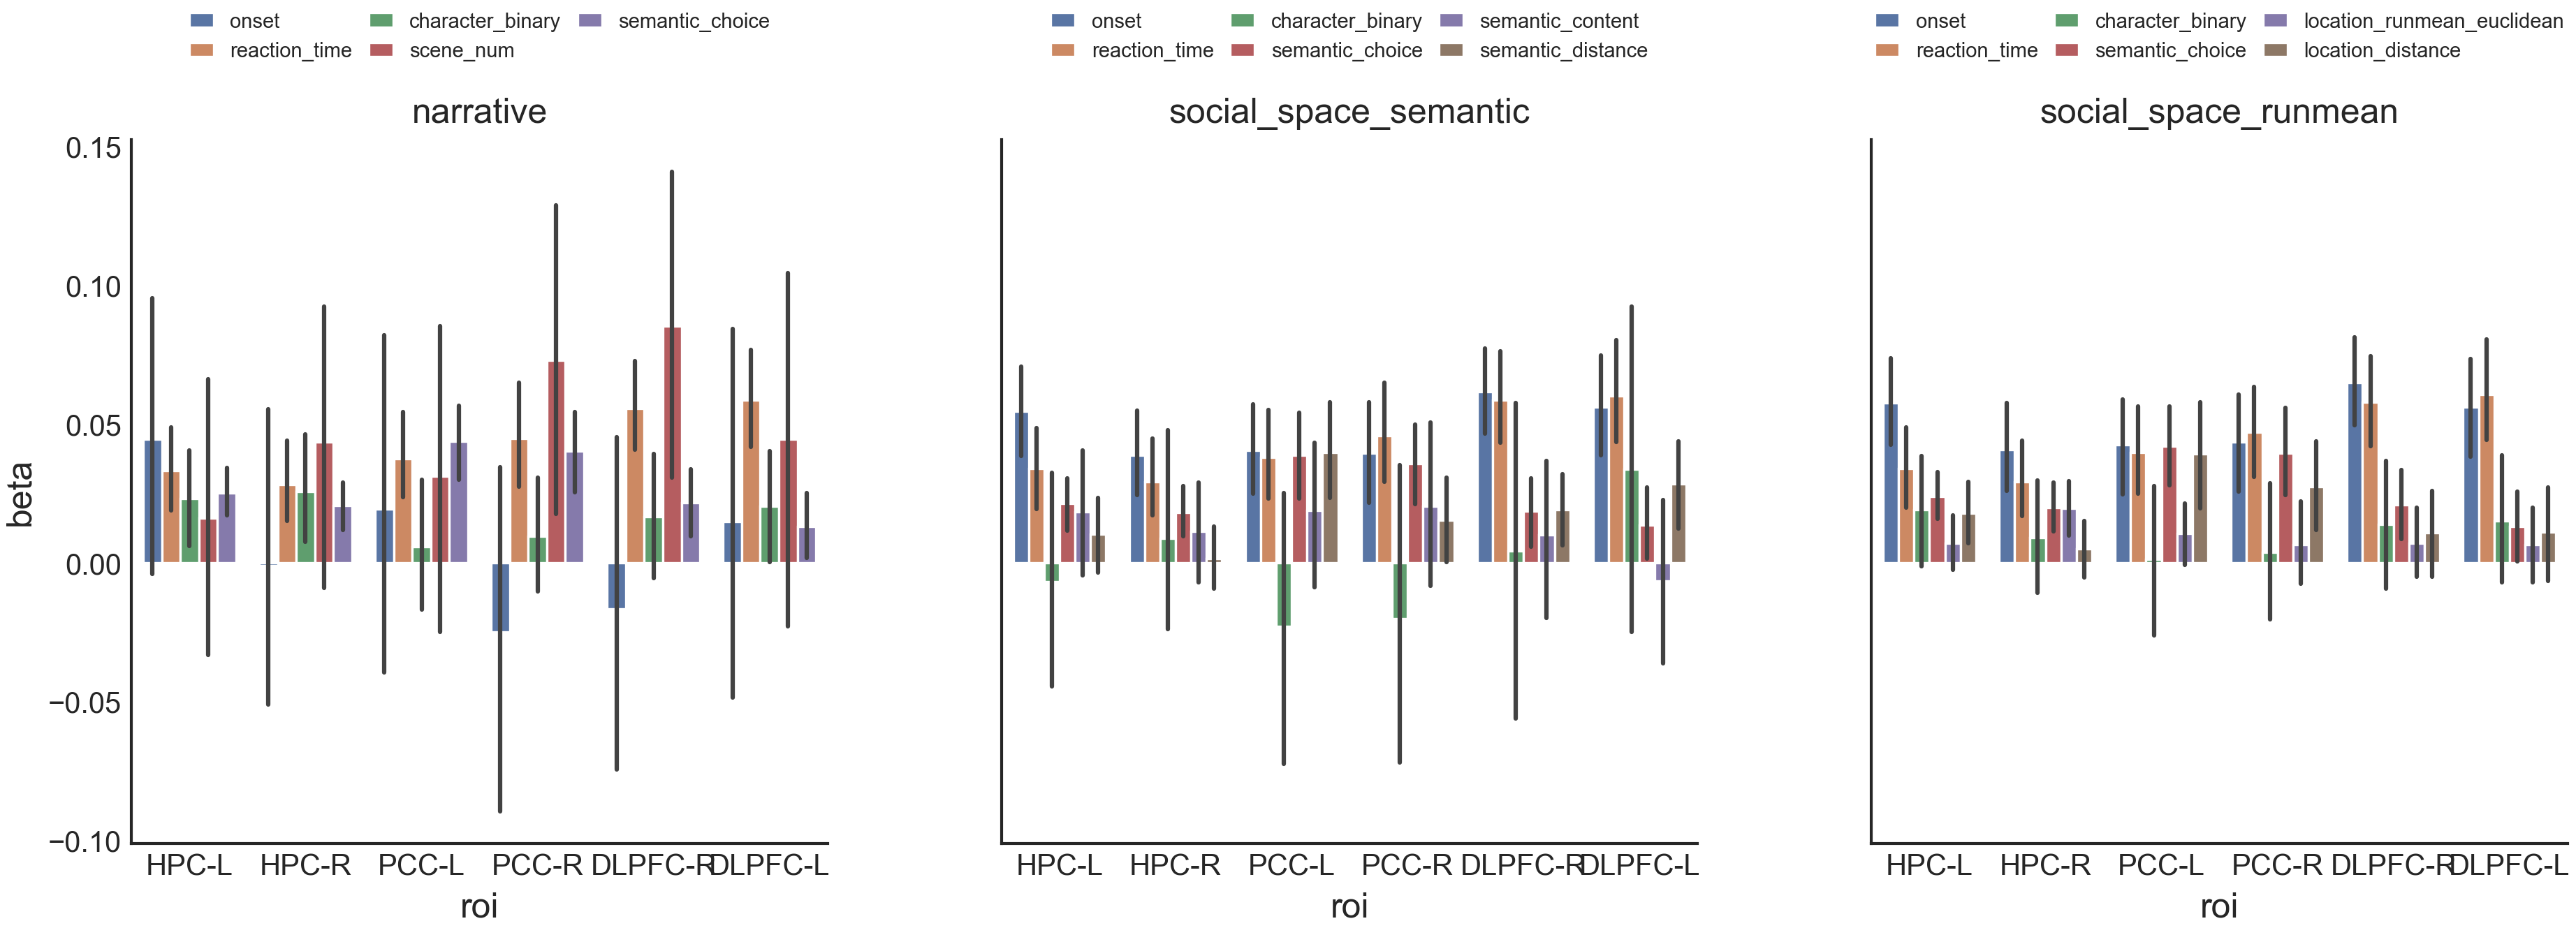

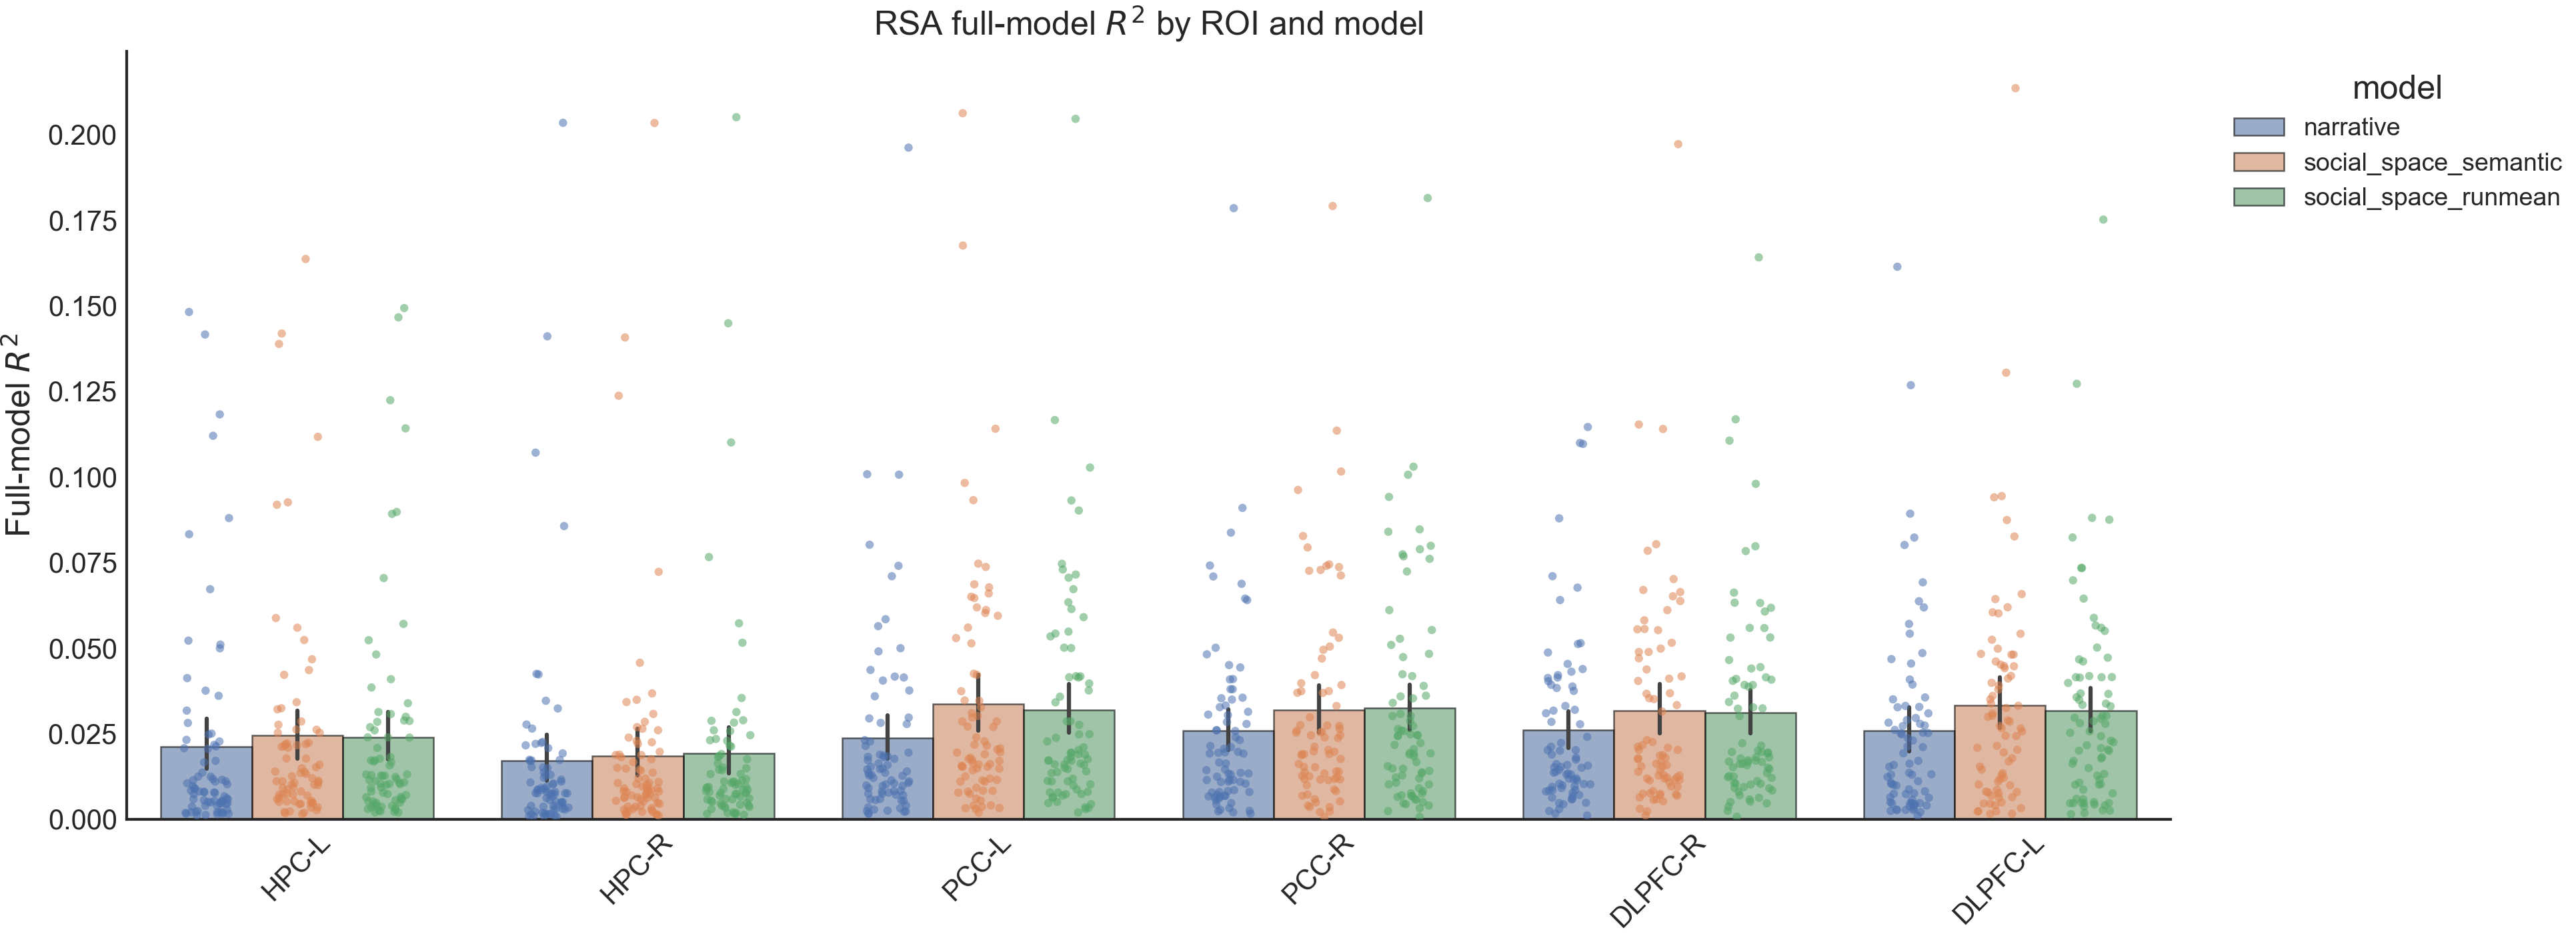

In [12]:
from scipy.spatial.distance import pdist
import hashlib

def make_design(
    behavior: pd.DataFrame,
    columns: list[str],
    *,
    drop_first_char: bool = True,   # 5 chars -> return 4 columns
    binary_tol: float = 1e-8,
    eps: float = 1e-12,
):
    """
    Build a PAIRWISE design DataFrame from trial-level behavior.

    Output:
      - rows: T*(T-1)/2 upper triangle (k=1)
      - columns: as requested in `columns`, with special cases:
        - "location_cosine": cosine distance on ("affil_coord", "power_coord"), trialwise z-scored per dim
        - "location_euclidean": euclidean distance on ("affil_coord", "power_coord"), trialwise z-scored per dim
        - "location_runmean_cosine": cosine distance on ("affil_runmean","power_runmean"), z-scored per dim
        - "location_runmean_euclidean": euclidean distance on ("affil_runmean","power_runmean"), z-scored per dim
        - "location_variability": per-trial (character-specific) running mean of within-character
          pairwise cosine distances among location vectors up to that trial; then pairwise euclidean
          distances on that scalar (|var_i - var_j|)
        - "choice": cosine SIMILARITY between 2D choice vectors ("affil_decision","power_decision"),
          after trialwise z-scoring per dim; similarity = 1 - cosine_distance
        - "character": dummy-coded XOR columns from "character_role_num" levels (K-1 if drop_first_char)
        - "character_binary": single regressor = 1 if different character else 0 (mean-centered)
        - "onset": |onset_i - onset_j|
        - "onset_sq": |onset_i - onset_j|^2 (derived from onset)

    Standardization
    ---------------
      - All continuous regressors are z-scored (mean 0, sd 1).
      - Binary regressors (0/1; e.g., mismatch/XOR) are mean-centered (subtract column mean).
    """

    METRIC_LOOKUP = {
        "reaction_time": "euclidean",
        "dimension": "mismatch",   # expects strings like "affil"/"power"
        "character_role_num": "mismatch",
        "affil_coord": "euclidean",
        "power_coord": "euclidean",
    }

    def _is_binary_like(x):
        x = np.asarray(x, float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return False
        q = np.round(x / binary_tol) if binary_tol > 0 else x
        return np.unique(q).size == 2

    def _zscore(x):
        x = np.asarray(x, float)
        mu = np.nanmean(x)
        sd = np.nanstd(x, ddof=1)
        if not np.isfinite(sd) or sd <= 0:
            return np.zeros_like(x, dtype=float)
        return (x - mu) / (sd + eps)

    def _mean_center(x):
        x = np.asarray(x, float)
        mu = np.nanmean(x)
        if not np.isfinite(mu):
            return np.zeros_like(x, dtype=float)
        return x - mu

    def _pairwise_1d(x, metric):
        n = len(x)
        iu, ju = np.triu_indices(n, k=1)

        if metric in {"mismatch", "match"}:
            codes = pd.factorize(pd.Series(x), sort=False)[0]  # missing -> -1
            ai, aj = codes[iu], codes[ju]
            if metric == "mismatch":
                return (ai != aj).astype(float)
            else:
                return (ai == aj).astype(float)

        x = np.asarray(pd.to_numeric(x, errors="coerce"), float)
        return pdist(x[:, None], metric=metric)

    def _standardize_rdv(rdv, metric):
        return _mean_center(rdv) if metric in {"mismatch", "match"} else _zscore(rdv)

    def _trialwise_location_variability(XY2d: np.ndarray, roles: np.ndarray) -> np.ndarray:
        """
        XY2d: (T,2) float (can include NaNs)
        roles: (T,) character ids (can include NaNs)
        Returns:
          var_trial: (T,) where var_trial[t] is the mean pairwise cosine distance among
                     that character's location vectors up through that character's current trial.
        """
        XY2d = np.asarray(XY2d, float)
        roles = np.asarray(roles)

        T = XY2d.shape[0]
        out = np.full(T, np.nan, dtype=float)

        # iterate characters in order of first appearance (stable)
        for c in pd.unique(roles):
            if pd.isna(c):
                continue

            idx = np.flatnonzero(roles == c)
            if idx.size == 0:
                continue

            Xc = XY2d[idx, :]  # (n,2)
            n = Xc.shape[0]
            dc = np.zeros(n, dtype=float)

            for k in range(n):
                Xk = Xc[: k + 1, :]

                # drop non-finite rows within the running window
                ok = np.isfinite(Xk).all(axis=1)
                Xk = Xk[ok, :]

                if Xk.shape[0] < 2:
                    dc[k] = 0.0
                else:
                    U = Xk / np.maximum(np.linalg.norm(Xk, axis=1, keepdims=True), eps)
                    dc[k] = float(pdist(U, metric="cosine").mean())

            out[idx] = dc

        return out

    out = {}

    for col in columns:

        if col == "location_cosine":
            XY  = behavior[["affil_coord", "power_coord"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])
            rdv = pdist(XYz, metric="cosine").astype(float)
            out["location_cosine"] = _standardize_rdv(rdv, metric="cosine").astype(float)
            continue

        if col == "location_euclidean":
            XY  = behavior[["affil_coord", "power_coord"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])
            rdv = pdist(XYz, metric="euclidean").astype(float)
            out["location_euclidean"] = _standardize_rdv(rdv, metric="euclidean").astype(float)
            continue

        if col == "location_runmean_cosine":
            XY  = behavior[["affil_runmean", "power_runmean"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])
            rdv = pdist(XYz, metric="cosine").astype(float)
            out["location_runmean_cosine"] = _standardize_rdv(rdv, metric="cosine").astype(float)
            continue

        if col == "location_runmean_euclidean":
            XY  = behavior[["affil_runmean", "power_runmean"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])
            rdv = pdist(XYz, metric="euclidean").astype(float)
            out["location_runmean_euclidean"] = _standardize_rdv(rdv, metric="euclidean").astype(float)
            continue

        # --- NEW: choice cosine similarity ---
        if col == "choice":
            if not all(c in behavior.columns for c in ("affil_decision", "power_decision")):
                raise KeyError("'choice' requires 'affil_decision' and 'power_decision' in behavior.")

            XY  = behavior[["affil_decision", "power_decision"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])

            # pdist cosine returns cosine DISTANCE = 1 - cosine_similarity
            d = pdist(XYz, metric="cosine").astype(float)
            sim = 1.0 - d

            out["choice"] = _standardize_rdv(sim, metric="cosine").astype(float)
            continue

        # --- location variability (accept alias if you previously used "location_distance") ---
        if col in {"location_variability", "location_distance"}:

            if "character_role_num" not in behavior.columns:
                raise KeyError(f"'{col}' requires column 'character_role_num' in behavior.")
            if not all(c in behavior.columns for c in ("affil_decision", "power_decision")):
                raise KeyError(f"'{col}' requires 'affil_decision' and 'power_decision' in behavior.")

            roles = pd.to_numeric(behavior["character_role_num"], errors="coerce").to_numpy()
            XY = behavior[["affil_decision", "power_decision"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            XYz = np.column_stack([_zscore(XY[:, j]) for j in range(XY.shape[1])])

            var_trial = _trialwise_location_variability(XYz, roles)  # (T,)
            rdv = pdist(var_trial[:, None], metric="euclidean").astype(float)
            out[col] = _standardize_rdv(rdv, metric="euclidean").astype(float)
            continue

        if col == "character_decision_num":
            X  = behavior["character_decision_num"].apply(pd.to_numeric, errors="coerce").to_numpy(float)
            Xz = _zscore(X)
            rdv = pdist(Xz[:, None], metric="euclidean").astype(float)
            out["character_decision_num"] = _standardize_rdv(rdv, metric="euclidean").astype(float)
            continue

        if col == "character":
            if "character_role_num" not in behavior.columns:
                raise KeyError("'character' requires column 'character_role_num' in behavior.")

            c = pd.to_numeric(behavior["character_role_num"], errors="coerce").astype("Int64")
            levels = sorted([v for v in c.dropna().unique()])

            if drop_first_char and len(levels) > 1:
                levels = levels[1:]

            for lvl in levels:
                indicator = (c == lvl).to_numpy(int)
                rdv = _pairwise_1d(indicator, metric="mismatch")
                out[f"char_{lvl}"] = _standardize_rdv(rdv, metric="mismatch").astype(float)
            continue

        if col == "character_binary":
            if "character_role_num" not in behavior.columns:
                raise KeyError("'character_binary' requires column 'character_role_num' in behavior.")

            c = pd.to_numeric(behavior["character_role_num"], errors="coerce").astype("Int64")
            rdv = _pairwise_1d(c.to_numpy(object), metric="mismatch")
            out["character_binary"] = _standardize_rdv(rdv, metric="mismatch").astype(float)
            continue

        if col in {"onset", "onset_sq"}:
            if "onset" not in behavior.columns:
                raise KeyError("'onset' column required for onset-based regressors.")

            t = pd.to_numeric(behavior["onset"], errors="coerce").to_numpy(float)
            rdv = _pairwise_1d(t, metric="euclidean")
            if col == "onset_sq":
                rdv = rdv ** 2

            out[col] = _standardize_rdv(rdv, metric="euclidean").astype(float)
            continue

        # ---- default ----
        if col not in behavior.columns:
            raise KeyError(f"Column not found in behavior: {col!r}")

        metric = METRIC_LOOKUP.get(col)
        if metric is None:
            if not pd.api.types.is_numeric_dtype(behavior[col]):
                metric = "mismatch"
            else:
                x_num = pd.to_numeric(behavior[col], errors="coerce").to_numpy(float)
                metric = "mismatch" if _is_binary_like(x_num) else "euclidean"

        if metric in {"mismatch", "match"}:
            x = behavior[col].to_numpy(object)
            rdv = _pairwise_1d(x, metric=metric)
            out[col] = _standardize_rdv(rdv, metric=metric).astype(float)
        else:
            x = pd.to_numeric(behavior[col], errors="coerce").to_numpy(float)
            x = _zscore(x)
            rdv = _pairwise_1d(x, metric=metric)
            out[col] = _standardize_rdv(rdv, metric=metric).astype(float)

    design_df = pd.DataFrame()
    for name, v in out.items():
        design_df[name] = np.asarray(v, float)

    return design_df

def embds_trialwise_stats(embds, *, trialwise_char_roles, eps=1e-12):
    """
    Per character, compute for each of its trials:
      1) mean direction (unit vector) of all embeddings up to that trial
      2) average pairwise cosine distance among those embeddings (via pdist)

    Uses trialwise_char_roles to correctly split and reassemble trials
    after dropping non-responses.
    """
    X = np.asarray(embds, float)
    if X.ndim != 2:
        raise ValueError(f"`embds` must be 2D (T,D); got {X.shape}")

    X_by_char = organize_by_character(
        X,
        trialwise_char_roles=trialwise_char_roles,
    )

    mu_by_char = []
    avgcos_by_char = []

    for Xc in X_by_char:
        Xc = np.asarray(Xc, float)
        n, D = Xc.shape

        muc = np.zeros((n, D), float)
        dc  = np.zeros(n, float)

        for k in range(n):
            Xk = Xc[:k+1]

            # mean direction
            m = Xk.mean(axis=0)
            nm = np.linalg.norm(m)
            muc[k] = m / max(nm, eps)

            # average pairwise cosine distance
            if k < 1:
                dc[k] = 0.0
            else:
                U = Xk / np.maximum(np.linalg.norm(Xk, axis=1, keepdims=True), eps)
                dc[k] = float(pdist(U, metric="cosine").mean())

        mu_by_char.append(muc)
        avgcos_by_char.append(dc)

    mu_trial = organize_by_trial(
        mu_by_char,
        trialwise_char_roles=trialwise_char_roles,
    )
    avgcos_trial = organize_by_trial(
        avgcos_by_char,
        trialwise_char_roles=trialwise_char_roles,
    )

    return mu_trial, avgcos_trial

def run_rsa_models_per_roi(
    subject_data: dict,
    rois: list[str],
    models: dict[str, list[str]],
    *,
    n_perm: int = 500,
    drop_first_char: bool = True,
):
    """
    Simple RSA runner

    Returns
    -------
    df_betas : pd.DataFrame
        Regressor-level beta results
    df_r2 : pd.DataFrame
        Subject-level full-model R² results
    """

    def stable_seed(*parts):
        return abs(hash("|".join(map(str, parts)))) % (2**32)

    def expand_tokens(toks):
        return list(toks)

    beta_rows = []
    r2_rows = []

    expanded = {m: expand_tokens(toks) for m, toks in models.items()}

    for sub_id, sd in subject_data.items():

        behav = drop_neutral_trials(sd["behavior"])
        resp_mask = behav["responded"].to_numpy(float)
        behav = behav[resp_mask == 1].reset_index(drop=True)
        char_roles = behav["character_role_num"].to_numpy()

        # ---------- precompute embedding-derived quantities ----------
        needs_choice_sem = any("semantic_choice" in cols for cols in expanded.values())
        needs_sem_cont   = any("semantic_content" in cols for cols in expanded.values())
        needs_sem_dist   = any("semantic_distance" in cols for cols in expanded.values())

        if needs_choice_sem or needs_sem_cont or needs_sem_dist:
            embds = drop_neutral_trials(sd["embds_noctxt"])
            embds = embds[resp_mask == 1]
            embds = np.asarray(embds, float)

        if needs_choice_sem:
            choice_sem_rdv = pdist(embds, metric="cosine")
            choice_sem_rdv = (choice_sem_rdv - choice_sem_rdv.mean()) / (
                choice_sem_rdv.std(ddof=1) + 1e-12
            )

        if needs_sem_cont or needs_sem_dist:
            mu_trial, avgcos_trial = embds_trialwise_stats(
                embds, trialwise_char_roles=char_roles
            )

        if needs_sem_cont:
            sem_cont_rdv = pdist(mu_trial, metric="cosine")
            sem_cont_rdv = (sem_cont_rdv - sem_cont_rdv.mean()) / (
                sem_cont_rdv.std(ddof=1) + 1e-12
            )

        if needs_sem_dist:
            sem_dist_rdv = pdist(avgcos_trial[:, None], metric="euclidean")
            sem_dist_rdv = (sem_dist_rdv - sem_dist_rdv.mean()) / (
                sem_dist_rdv.std(ddof=1) + 1e-12
            )

        # ---------- RSA per ROI ----------
        for roi in rois:
            X = drop_neutral_trials(sd["roi_betas"][roi])
            X = X[resp_mask == 1]
            y = make_neural_rdv(X)

            for model_name, cols in expanded.items():

                base_cols = [
                    c for c in cols
                    if c not in ("semantic_choice", "semantic_content", "semantic_distance")
                ]

                design_df = make_design(
                    behav,
                    base_cols,
                    drop_first_char=drop_first_char,
                )

                if "semantic_choice" in cols:
                    design_df["semantic_choice"] = choice_sem_rdv
                if "semantic_content" in cols:
                    design_df["semantic_content"] = sem_cont_rdv
                if "semantic_distance" in cols:
                    design_df["semantic_distance"] = sem_dist_rdv

                beta_df, r2_df = fit_rsa_regression_freedman_lane(
                    y,
                    design_df=design_df,
                    n_perm=n_perm,   # can be 1; R² uses observed only
                    seed=stable_seed(sub_id, roi, model_name),
                )

                # ---------- store betas ----------
                for reg, row in beta_df.iterrows():
                    beta_rows.append(
                        {
                            "sub_id": str(sub_id),
                            "roi": str(roi),
                            "model": str(model_name),
                            "regressor": str(reg),
                            "beta": float(row["beta"]),
                            "null_mean": float(row["null_mean"]),
                            "null_sd": float(row["null_sd"]),
                            "z": float(row["z"]),
                            "n_pairs": int(y.size),
                            "n_perm": int(n_perm),
                        }
                    )

                # ---------- store full-model R² ----------
                r2_rows.append(
                    {
                        "sub_id": str(sub_id),
                        "roi": str(roi),
                        "model": str(model_name),
                        "r2": float(r2_df["r2"].iloc[0]),
                        "n_pairs": int(y.size),
                    }
                )

    return pd.DataFrame(beta_rows), pd.DataFrame(r2_rows)

models = {
    "narrative": ["onset", "reaction_time", "character_binary", "scene_num", "semantic_choice"], 
    "social_space_semantic":  ["onset", "reaction_time", "character_binary", "semantic_choice", "semantic_content", "semantic_distance"],  
    "social_space_runmean":  ["onset", "reaction_time", "character_binary", "semantic_choice", "location_runmean_euclidean", "location_distance"],  
    # "social_space_hybrid":  ["onset", "reaction_time", "character_binary", "semantic_choice", "location_runmean_euclidean", "semantic_distance"],  
    # "social_space_2d_tavares":  ["onset", "reaction_time", "character_binary", "semantic", "distance", "theta"],  # THIS NEEDS WORK...
}

#---------------------------- run RSA

subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares-striatum.pkl")
subject_data = {k: v for k, v in subject_data.items() if k in incl_subs}

ROIS = ['HPC-L', 'HPC-R', 'PCC-L', 'PCC-R', 'DLPFC-R', 'DLPFC-L']

df_rsa, df_r2 = run_rsa_models_per_roi(
    subject_data,
    ROIS,
    models=models,
    n_perm=1,   # permutations ignored for R²
)

#---------------------------- plot

model_order = list(models.keys())
df_rsa["model"] = pd.Categorical(df_rsa["model"], categories=model_order, ordered=True)

# only plot models that actually exist in df_rsa (in your specified order)
models_to_plot = [m for m in model_order if m in set(df_rsa["model"].dropna().astype(str))]

n_models = len(models_to_plot)
ncols = min(3, n_models)
nrows = math.ceil(n_models / ncols)

fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(5 * ncols, 4 * nrows),
    constrained_layout=False,
    sharey=True,
    squeeze=False
)
fig.subplots_adjust(hspace=0.55, wspace=0.25, top=0.95)

for i, model in enumerate(models_to_plot):
    r, c = divmod(i, ncols)
    ax = axs[r, c]
    df_model = df_rsa[df_rsa["model"].astype(str) == model].copy()
    reg_order = models[model]
    df_model["regressor"] = pd.Categorical(df_model["regressor"], categories=reg_order, ordered=True)

    ax.set_title(str(model))
    sns.barplot(
        data=df_model,
        x="roi",
        y="beta",
        hue="regressor",
        hue_order=reg_order,
        ax=ax
    )

    # --- force legend order to match reg_order ---
    handles, labels = ax.get_legend_handles_labels()

    # seaborn/mpl sometimes gives duplicates; keep first occurrence
    first = {}
    for h, lab in zip(handles, labels):
        if lab not in first:
            first[lab] = h

    # keep only labels that are actually present, in your desired order
    ordered_labels = [lab for lab in reg_order if lab in first]
    ordered_handles = [first[lab] for lab in ordered_labels]

    nleg = min(3, len(ordered_labels))
    ax.legend(
        ordered_handles,
        ordered_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.1),
        ncol=nleg,
        frameon=False,
        borderaxespad=0.0,
        handlelength=1.2,
        columnspacing=0.8,
        fontsize=7,
        title=None
    )

# ---------------------------- plot R² (full model)

model_order = list(models.keys())
df_r2["model"] = pd.Categorical(df_r2["model"], categories=model_order, ordered=True)

rois_to_plot = [r for r in ROIS if r in set(df_r2["roi"])]
df_plot = df_r2[df_r2["roi"].isin(rois_to_plot)].copy()
df_plot["roi"] = pd.Categorical(df_plot["roi"], categories=rois_to_plot, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(1.2 * len(rois_to_plot) + 6, 5))

# bars (means by default; set estimator=np.mean explicitly if you want)
sns.barplot(
    data=df_plot,
    x="roi",
    y="r2",
    hue="model",
    hue_order=model_order,
    ax=ax,
    dodge=True,
    errorbar=("ci", 95),   # seaborn>=0.12; use ci=95 if older
    edgecolor="black",
    linewidth=0.6,
    alpha=0.6,
)

# strip overlay (all points)
sns.stripplot(
    data=df_plot,
    x="roi",
    y="r2",
    hue="model",
    hue_order=model_order,
    ax=ax,
    dodge=True,
    jitter=0.20,
    alpha=0.55,
    size=3,
    linewidth=0.0,
)

# ---- fix duplicated legends (barplot + stripplot both add one) ----
handles, labels = ax.get_legend_handles_labels()
# keep only first occurrence of each model label, in order
first = {}
for h, lab in zip(handles, labels):
    if lab not in first and lab in set(map(str, model_order)):
        first[lab] = h
ordered_labels = [str(m) for m in model_order if str(m) in first]
ordered_handles = [first[lab] for lab in ordered_labels]
ax.legend(
    ordered_handles,
    ordered_labels,
    title="model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)

ax.set_xlabel("")
ax.set_ylabel("Full-model $R^2$")
ax.set_title("RSA full-model $R^2$ by ROI and model")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()


## test across subjects, controlling for covariates

In [25]:
covariates_second_level = ['sex', 'fd_mean', 'missing_trials', 'memory_mean']
terms = ['lsas_av_score', 'dx']
model = "social_space_2d_runmean_euclidean"
regr  = "character_decision_num"
alpha = 0.05

def _tokens_from_term(term: str) -> list[str]:
    """
    Map a formula chunk to the parameter names statsmodels will report in `res["x"]`.

    - 'a * b' expands to ['a', 'b', 'a:b']
    - 'a:b' returns ['a:b']
    - 'a' returns ['a']
    """
    t = term.replace(" ", "")
    if "*" in t:
        parts = [p for p in t.split("*") if p]
        out = []
        out += parts
        if len(parts) >= 2:
            # include all pairwise interactions as statsmodels does for *
            for i in range(len(parts)):
                for j in range(i + 1, len(parts)):
                    out.append(f"{parts[i]}:{parts[j]}")
        return out
    if ":" in t:
        return [t]
    return [t]

# which rows to check for significance
tokens_to_check = []
for t in terms:
    tokens_to_check.extend(_tokens_from_term(t))
tokens_to_check = sorted(set(tokens_to_check))

for roi in ROIS:
    df_model = df_rsa[
        (df_rsa["model"] == model)
        & (df_rsa["regressor"] == regr)
        & (df_rsa["roi"] == roi)
    ].copy()

    df_model["sub_id"] = df_model["sub_id"].astype(int)
    df_model = df_model.merge(data, how="left", on="sub_id")

    formula = f'beta ~ {" + ".join(terms)} + {" + ".join(covariates_second_level)}'
    res = run_regression(formula, data=df_model, scale_x=True, scale_y=False)

    # pull rows corresponding to the expanded terms (incl. interactions)
    sub = res.loc[res["x"].isin(tokens_to_check)].copy()

    sig = (
        sub.assign(alpha=alpha)
           .query("p < alpha")
           .loc[:, ["x", "beta", "se", "t", "p", "p_left", "p_right", "95%_lb", "95%_ub"]]
           .sort_values("p")
    )

    print(f"\nROI: {roi}")
    if sub.empty:
        print("  (No matching term rows found in regression output; check naming in res['x']. )")
        continue

    if sig.empty:
        print(f"  No specified term(s) significant at p < {alpha}")
    else:
        for r in sig.itertuples(index=False):
            print(f"  {r.x}: beta={r.beta:.3f}, t={r.t:.3f}, p={r.p:.3g}")

    # Optional: always show a compact summary for the checked rows (sig or not)
    # print_df(sub.loc[:, ["x","beta","se","t","p"]].round(3))


Error during OLS/WLS fitting: zero-size array to reduction operation maximum which has no identity


KeyError: 'x'